## Using python built-in multiprocessing

[Worker 0] Starting with 10 tasks


[Worker 1] Starting with 2 tasks
[Worker 2] Starting with 0 tasks
[Worker 3] Starting with 0 tasks
[Worker 0] Sent 4 tasks to 1
[Worker 0] Sent 2 tasks to 2[Worker 2] Stole 2 tasks

[Worker 1] Stole 4 tasks


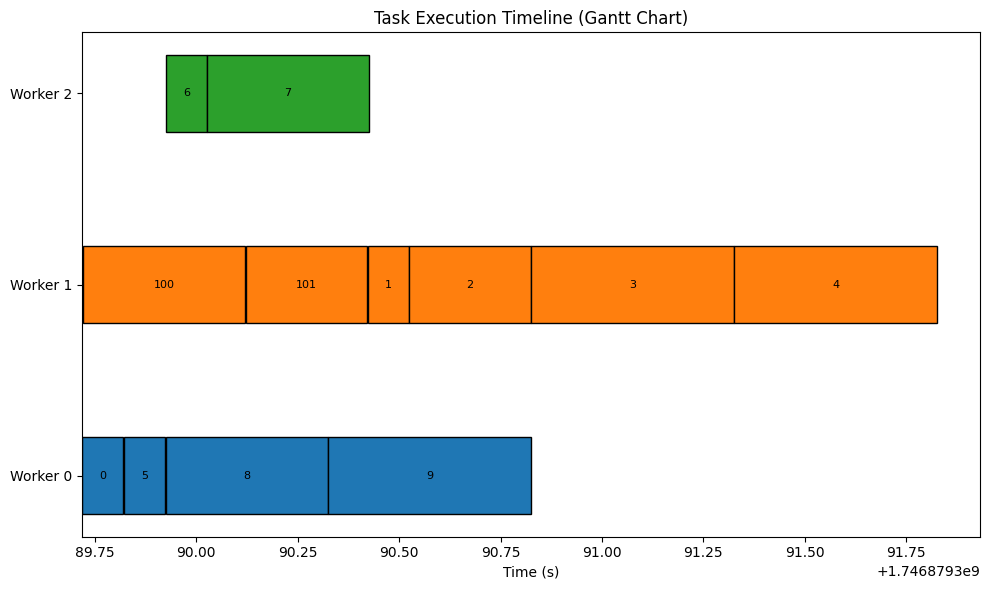

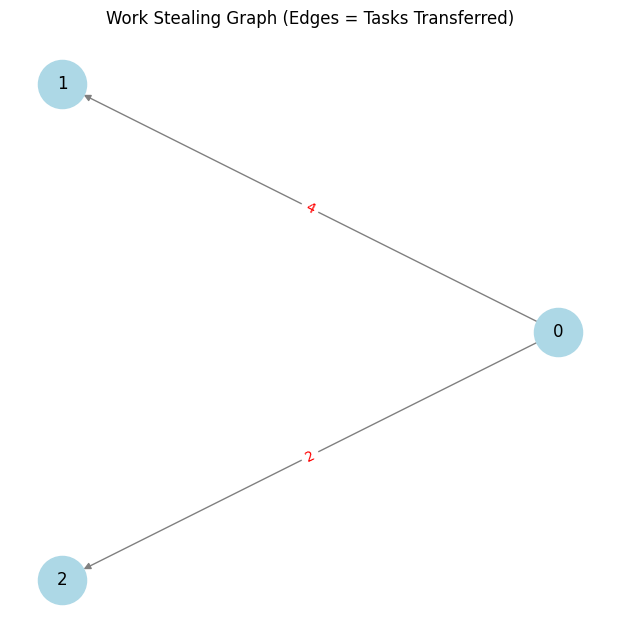

In [4]:
import multiprocessing as mp
import time
import random
from typing import List, Tuple
import matplotlib.pyplot as plt
import networkx as nx


def heavy_task(task_id: int, duration: int, worker_id: int) -> Tuple[int, int, float, float]:
    start = time.time()
    time.sleep(duration * 0.1)  # Simulate computation
    end = time.time()
    return (worker_id, task_id, start, end)


def worker(worker_id: int, task_queues, result_queue, steal_log, num_workers: int):
    local_queue = []

    # Seed some workers
    if worker_id == 0:
        local_queue.extend([(i, random.randint(1, 5)) for i in range(10)])
    elif worker_id == 1:
        local_queue.extend([(i + 100, random.randint(1, 5)) for i in range(2)])

    print(f"[Worker {worker_id}] Starting with {len(local_queue)} tasks")

    while True:
        if local_queue:
            task_id, duration = local_queue.pop(0)
            result = heavy_task(task_id, duration, worker_id)
            result_queue.put(result)

            if len(local_queue) > 3:
                for i in range(num_workers):
                    if i != worker_id and task_queues[i].empty():
                        chunk = local_queue[:len(local_queue) // 2]
                        local_queue = local_queue[len(local_queue) // 2:]
                        task_queues[i].put(chunk)
                        steal_log.append((worker_id, i, len(chunk), time.time()))
                        print(f"[Worker {worker_id}] Sent {len(chunk)} tasks to {i}")
                        break
        else:
            try:
                stolen = task_queues[worker_id].get(timeout=0.5)
                local_queue.extend(stolen)
                print(f"[Worker {worker_id}] Stole {len(stolen)} tasks")
            except:
                break

    result_queue.put((worker_id, "Done"))


def plot_gantt(task_logs: List[Tuple[int, int, float, float]]):
    fig, ax = plt.subplots(figsize=(10, 6))
    colors = plt.cm.tab10.colors

    for log in task_logs:
        worker_id, task_id, start, end = log
        ax.barh(
            y=worker_id,
            width=end - start,
            left=start,
            height=0.4,
            color=colors[worker_id % len(colors)],
            edgecolor='black',
        )
        ax.text((start + end) / 2, worker_id, f"{task_id}", ha='center', va='center', fontsize=8)

    ax.set_yticks(range(max(w for w, *_ in task_logs) + 1))
    ax.set_yticklabels([f"Worker {i}" for i in range(max(w for w, *_ in task_logs) + 1)])
    ax.set_xlabel("Time (s)")
    ax.set_title("Task Execution Timeline (Gantt Chart)")
    plt.tight_layout()
    plt.show()


def plot_stealing_graph(steal_log: List[Tuple[int, int, int, float]]):
    G = nx.DiGraph()
    steal_counts = {}

    for from_id, to_id, num_tasks, _ in steal_log:
        G.add_edge(from_id, to_id)
        steal_counts[(from_id, to_id)] = steal_counts.get((from_id, to_id), 0) + num_tasks

    pos = nx.circular_layout(G)
    edge_labels = {edge: f"{steal_counts[edge]}" for edge in G.edges()}

    plt.figure(figsize=(6, 6))
    nx.draw(G, pos, with_labels=True, node_color='lightblue', edge_color='gray', node_size=1200, font_size=12)
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red')
    plt.title("Work Stealing Graph (Edges = Tasks Transferred)")
    plt.show()


def run_simulation(num_workers=4):
    manager = mp.Manager()
    task_queues = [manager.Queue() for _ in range(num_workers)]
    result_queue = manager.Queue()
    steal_log = manager.list()

    processes = [
        mp.Process(target=worker, args=(i, task_queues, result_queue, steal_log, num_workers))
        for i in range(num_workers)
    ]

    for p in processes:
        p.start()

    task_logs = []
    done_count = 0

    while done_count < num_workers:
        msg = result_queue.get()
        if isinstance(msg, tuple) and msg[1] == "Done":
            done_count += 1
        else:
            task_logs.append(msg)

    for p in processes:
        p.join()

    task_logs.sort(key=lambda x: x[2])  # Sort by start time
    plot_gantt(task_logs)
    plot_stealing_graph(list(steal_log))


if __name__ == "__main__":
    run_simulation(num_workers=4)
